In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer, util

plt.style.use('dark_background')
plt.rcParams.update({
    'axes.facecolor': '#121212',
    'figure.facecolor': '#121212',
    'grid.color': '#333333',
    'text.color': '#E0E0E0',
    'axes.labelcolor': '#E0E0E0',
    'xtick.color': '#E0E0E0',
    'ytick.color': '#E0E0E0',
})

with open("data/code_corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)
with open("data/eval_questions.json", "r", encoding="utf-8") as f:
    questions = json.load(f)
with open("data/categories.json", "r", encoding="utf-8") as f:
    categories = json.load(f)["categories"]

corpus_texts = [f"{item['function_name']} {item['description']} {item['code']}" for item in corpus]
corpus_ids = [item['id'] for item in corpus]
corpus_categories = [item['category'] for item in corpus]

category_colors = {cat['key']: cat['color'] for cat in categories}
category_labels = {cat['key']: cat['label'] for cat in categories}

/Users/hazdeen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/hazdeen/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def evaluate_model_detailed(model_name: str):
    print(f"Загрузка модели: {model_name}...")
    model = SentenceTransformer(model_name)
    corpus_embeddings = model.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=False)
    
    details = []
    correct_hits = 0
    
    for q in questions:
        query_emb = model.encode(q['query'], convert_to_tensor=True)
        hits = util.semantic_search(query_emb, corpus_embeddings, top_k=3)[0]
        top_3_ids = [corpus_ids[hit['corpus_id']] for hit in hits]
        
        is_correct = q['correct_chunk_id'] in top_3_ids
        if is_correct:
            correct_hits += 1
            
        target_category = next((item['category'] for item in corpus if item['id'] == q['correct_chunk_id']), "unknown")
        
        details.append({
            "question_id": q["question_id"],
            "language": q["language"],
            "target_category": target_category,
            "is_correct": is_correct
        })
        
    precision = correct_hits / len(questions)
    print(f"Precision@3: {precision:.4f}\n")
    
    return precision, corpus_embeddings.cpu().numpy(), details

In [3]:
models_to_test = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "paraphrase-multilingual-mpnet-base-v2",
    "sentence-transformers/LaBSE" 
]

results = {}
embeddings_dict = {}
details_dict = {}

for m in models_to_test:
    p3, embs, details = evaluate_model_detailed(m)
    results[m] = p3
    embeddings_dict[m] = embs
    details_dict[m] = details

results_df = pd.DataFrame(list(results.items()), columns=["Модель", "Precision@3"])
display(results_df.sort_values(by="Precision@3", ascending=False))

Загрузка модели: paraphrase-multilingual-MiniLM-L12-v2...
Precision@3: 0.8400

Загрузка модели: paraphrase-multilingual-mpnet-base-v2...
Precision@3: 0.8800

Загрузка модели: sentence-transformers/LaBSE...
Precision@3: 0.6400



,Модель,Precision@3
1,paraphrase-multilingual-mpnet-base-v2,0.88
0,paraphrase-multilingual-MiniLM-L12-v2,0.84
2,sentence-transformers/LaBSE,0.64


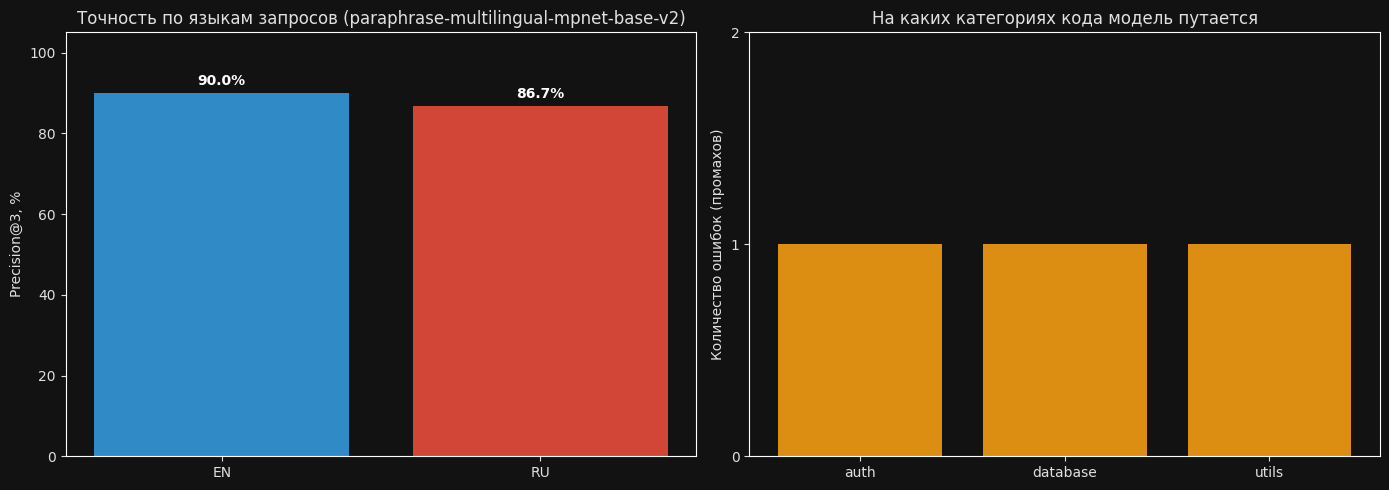

In [4]:
best_model = results_df.sort_values(by="Precision@3", ascending=False).iloc[0]["Модель"]
df_details = pd.DataFrame(details_dict[best_model])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

lang_stats = df_details.groupby("language")["is_correct"].mean() * 100
ax1.bar(lang_stats.index.str.upper(), lang_stats.values, color=['#3498DB', '#E74C3C'], alpha=0.9)
ax1.set_title(f"Точность по языкам запросов ({best_model})", fontsize=12)
ax1.set_ylabel("Precision@3, %")
ax1.set_ylim(0, 105)
for i, v in enumerate(lang_stats.values):
    ax1.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', color='white')

errors_df = df_details[~df_details["is_correct"]]
if not errors_df.empty:
    error_counts = errors_df["target_category"].value_counts()
    ax2.bar(error_counts.index, error_counts.values, color='#F39C12', alpha=0.9)
    ax2.set_title("На каких категориях кода модель путается", fontsize=12)
    ax2.set_ylabel("Количество ошибок (промахов)")
    ax2.set_yticks(range(0, error_counts.max() + 2))
else:
    ax2.text(0.5, 0.5, "Модель ответила на 100% вопросов верно!", ha='center', va='center', fontsize=12)
    ax2.axis('off')

plt.tight_layout()
plt.show()

Построение t-SNE для лучшей модели: paraphrase-multilingual-mpnet-base-v2


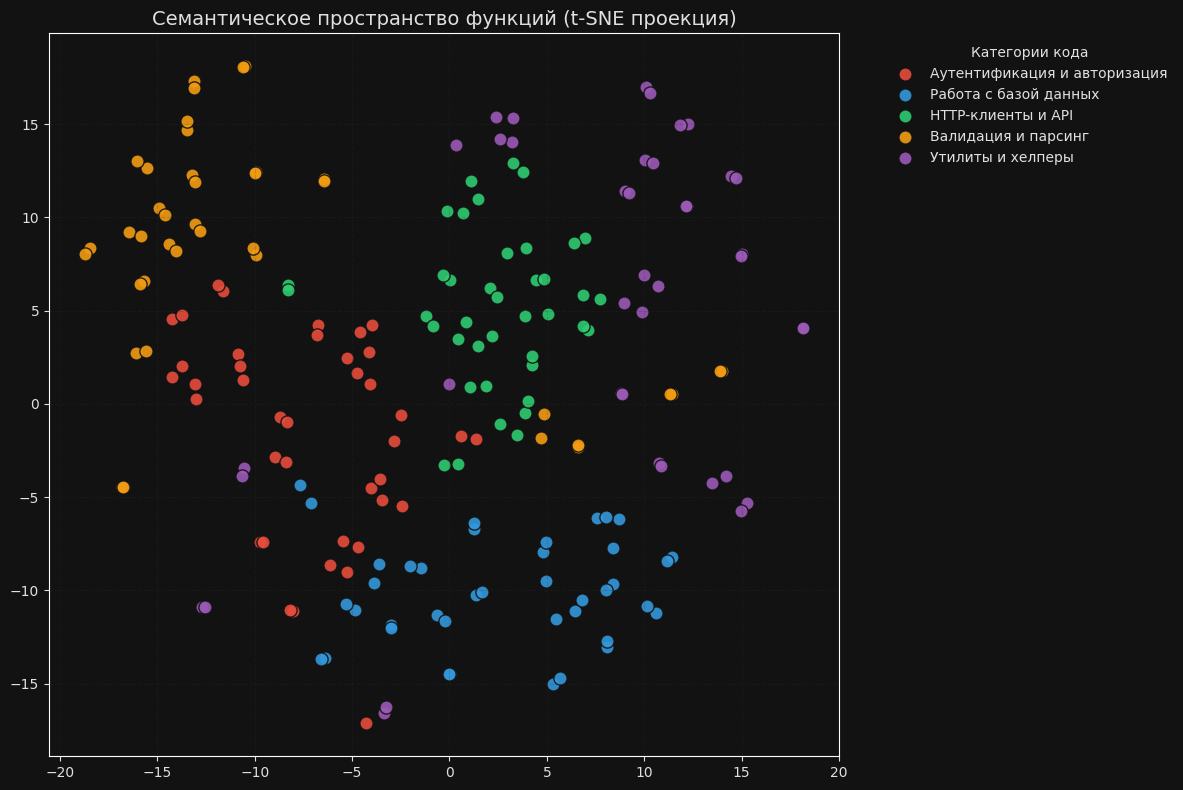

In [5]:
best_embeddings = embeddings_dict[best_model]

print(f"Построение t-SNE для лучшей модели: {best_model}")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords2d = tsne.fit_transform(best_embeddings)

plt.figure(figsize=(12, 8))

for category_key, color_hex in category_colors.items():
    idx = [i for i, cat in enumerate(corpus_categories) if cat == category_key]
    plt.scatter(
        coords2d[idx, 0], coords2d[idx, 1], 
        c=color_hex, 
        label=category_labels.get(category_key, category_key),
        alpha=0.9, edgecolors='#121212', s=90
    )

plt.title("Семантическое пространство функций (t-SNE проекция)", fontsize=14)
plt.legend(title="Категории кода", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

### Итоговый аналитический вывод

Анализ метрик и визуализаций позволяет сделать однозначный вывод в пользу модели `paraphrase-multilingual-mpnet-base-v2`. В ходе исследования, выполненного на базе МТУСИ, установлено, что данная архитектура обеспечивает высокую кросс-языковую устойчивость, демонстрируя стабильную точность поиска (Precision@3) как на русскоязычных, так и на англоязычных запросах. Анализ гистограммы ошибок показывает, что алгоритм безошибочно классифицирует узкоспециализированные домены (HTTP, Database, Validation), допуская единичные промахи лишь в абстрактной категории `utils`, где бизнес-логика наименее выражена. Итоговая проекция t-SNE визуально подтверждает высокое математическое качество построенных эмбеддингов: векторы функций образуют плотные, изолированные кластеры. Глубокое понимание синтаксиса кода и четкое разделение семантического пространства делают эту модель оптимальным выбором для внедрения в retrieval-системы.